# OpenWEC — Le Mans 2026 Analysis

This notebook demonstrates the OpenWEC Python SDK using the 2026 24 Hours of Le Mans as a case study.

**What we'll cover:**
- Loading race results and lap data
- Analyzing HYPERCAR stint strategies
- Comparing pace across manufacturers
- Visualizing gap to leader and lap evolution

**Requirements:**
```bash
pip install openwec[plotting]
```

**API key:** Public endpoints (results) work without a key. Laps and analytics require a free key — [request one here](https://openwec.com/api-keys).

## 1. Setup

In [1]:
import openwec
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Load API key from .env file
env_file = Path(".env")
if env_file.exists():
    for line in env_file.read_text().splitlines():
        if line.startswith("API_KEYS="):
            key = line.split("=", 1)[1].strip().split(",")[0]
            os.environ.setdefault("OPENWEC_API_KEY", key)

openwec.configure(
    api_key=os.environ.get("API_KEYS", "")
)

print(f"openwec {openwec.__version__}")

openwec 0.1.0-alpha


## 2. Load the session

In [2]:
session = openwec.Session("WEC", 2026, "Le Mans", "Race")
print(session)

Session(WEC 2026 LE MANS — Race, id=6556)


Expected output:
```
Session(WEC 2026 LE MANS — Race, id=6556)
```

## 3. Race results

Results are public — no API key required.

In [3]:
results = session.results()
print(f"{len(results)} cars classified")
results.head(10)

62 cars classified


,position,car_number,car_class,vehicle,team,tyre_supplier,status,laps_completed,total_time_s,gap_to_first_s,fl_lap_number,fl_time_s,fl_kph,drivers
0,1,7,HYPERCAR,Toyota TR010 Hybrid,Toyota Racing,None,Classified,381,86581.030,NaN,303,205.155,239.1,Mike CONWAY / Kamui KOBAYASHI / Nyck DE VRIES
1,2,20,HYPERCAR,BMW M Hybrid V8,BMW M Team WRT,None,Classified,381,86591.943,10.913,304,205.607,238.6,Robin FRIJNS / Rene Rast / Sheldon VAN DER LINDE
2,3,8,HYPERCAR,Toyota TR010 Hybrid,Toyota Racing,None,Classified,381,86601.447,20.417,306,205.041,239.2,Sébastien BUEMI / Brendon HARTLEY / Ryo HIRAKAWA
3,4,12,HYPERCAR,Cadillac V-Series.R,Cadillac Hertz Team JOTA,None,Classified,381,86613.411,32.381,343,205.369,238.9,Louis DELÉTRAZ / Will STEVENS / Norman NATO
4,5,51,HYPERCAR,Ferrari 499P,Ferrari AF Corse,None,Classified,381,86723.453,142.423,303,206.154,237.9,Alessandro PIER GUIDI / James CALADO / Antonio...
5,6,35,HYPERCAR,Alpine A424,Alpine Endurance Team,None,Classified,381,86731.235,150.205,313,206.243,237.8,António FÉLIX DA COSTA / Charles MILESI / Ferd...
6,7,83,HYPERCAR,Ferrari 499P,AF Corse,None,Classified,381,86736.603,155.573,314,206.382,237.7,Yifei YE / Robert KUBICA / Phil Hanson
7,8,007,HYPERCAR,Aston Martin Valkyrie,Aston Martin Thor Team,None,Classified,379,86610.890,NaN,318,206.611,237.4,Harry TINCKNELL / Tom GAMBLE / Ross GUNN
8,9,101,HYPERCAR,Cadillac V-Series.R,Cadillac WTR,None,Classified,379,86639.236,NaN,286,206.368,237.7,Ricky TAYLOR / Jordan TAYLOR / Filipe ALBUQUERQUE
9,10,36,HYPERCAR,Alpine A424,Alpine Endurance Team,None,Classified,379,86706.622,NaN,300,206.399,237.7,Frédéric MAKOWIECKI / Jules GOUNON / Victor MA...


In [4]:
# HYPERCAR top 5
hypercar = results[results["car_class"] == "HYPERCAR"].copy()
hypercar[["position", "car_number", "team", "vehicle", "laps_completed", "gap_to_first_s", "drivers"]].head(5)

,position,car_number,team,vehicle,laps_completed,gap_to_first_s,drivers
0,1,7,Toyota Racing,Toyota TR010 Hybrid,381,NaN,Mike CONWAY / Kamui KOBAYASHI / Nyck DE VRIES
1,2,20,BMW M Team WRT,BMW M Hybrid V8,381,10.913,Robin FRIJNS / Rene Rast / Sheldon VAN DER LINDE
2,3,8,Toyota Racing,Toyota TR010 Hybrid,381,20.417,Sébastien BUEMI / Brendon HARTLEY / Ryo HIRAKAWA
3,4,12,Cadillac Hertz Team JOTA,Cadillac V-Series.R,381,32.381,Louis DELÉTRAZ / Will STEVENS / Norman NATO
4,5,51,Ferrari AF Corse,Ferrari 499P,381,142.423,Alessandro PIER GUIDI / James CALADO / Antonio...


In [5]:
# Winner info
winner = results[results["position"] == 1].iloc[0]
print(f"Winner: #{winner['car_number']} {winner['team']}")
print(f"Vehicle: {winner['vehicle']}")
print(f"Drivers: {winner['drivers']}")
print(f"Laps: {winner['laps_completed']}")
print(f"Fastest lap: {winner['fl_time_s']:.3f}s (lap {winner['fl_lap_number']})")

Winner: #7 Toyota Racing
Vehicle: Toyota TR010 Hybrid
Drivers: Mike CONWAY / Kamui KOBAYASHI / Nyck DE VRIES
Laps: 381
Fastest lap: 205.155s (lap 303)


## 4. Pace analysis

Average green-flag pace per car, sorted fastest first. Requires API key.

In [ ]:


pace = session.pace(car_class="HYPERCAR")
pace[["car_number", "team", "avg_pace_s", "best_lap_s", "consistency_s", "pit_stops"]].head(10)

,car_number,team,avg_pace_s,best_lap_s,consistency_s,pit_stops
0,20,BMW M Team WRT,218.097,205.607,28.125,30
1,38,Cadillac Hertz Team JOTA,218.105,117.000,30.581,20
2,12,Cadillac Hertz Team JOTA,218.280,205.369,28.530,34
3,8,Toyota Racing,219.376,205.041,31.787,32
4,51,Ferrari AF Corse,219.532,206.154,32.236,31
5,7,Toyota Racing,219.755,205.155,31.425,32
6,83,AF Corse,219.895,206.091,28.929,32
7,35,Alpine Endurance Team,219.922,206.243,31.752,31
8,50,Ferrari AF Corse,220.481,206.903,32.408,24
9,36,Alpine Endurance Team,220.613,206.399,31.405,31


In [11]:
# Average pace by manufacturer
# Merge with results to get vehicle info
pace_enriched = pace.merge(
    results[["car_number", "vehicle"]],
    on="car_number",
    how="left"
)

# Extract manufacturer from vehicle name
pace_enriched["manufacturer"] = pace_enriched["vehicle"].str.split().str[0]

manufacturer_pace = (
    pace_enriched.groupby("manufacturer")["avg_pace_s"]
    .mean()
    .sort_values()
    .reset_index()
)

print("Average HYPERCAR pace by manufacturer:")
for _, row in manufacturer_pace.iterrows():
    m = int(row['avg_pace_s'] // 60)
    s = row['avg_pace_s'] % 60
    print(f"  {row['manufacturer']:12s} {m}:{s:06.3f}")

Average HYPERCAR pace by manufacturer:
  Cadillac     3:39.248
  Toyota       3:39.565
  Ferrari      3:39.969
  BMW          3:40.095
  Alpine       3:40.267
  Genesis      3:41.345
  Aston        3:41.815
  Peugeot      3:42.683


## 5. Stint analysis

Stint boundaries, baseline pace, degradation rate, and consistency per stint per car.

In [12]:
stints = session.stints(car_class="HYPERCAR")
print(f"{len(stints)} stints total across HYPERCAR class")
stints.head(10)

550 stints total across HYPERCAR class


,car_number,car_class,team,stint_number,start_lap,end_lap,lap_count,tyre_age_laps,baseline_pace_s,degradation_s_per_lap,consistency_s,is_final_stint
0,007,HYPERCAR,Aston Martin Thor Team,1,1,12,12,11,210.853,0.0830,1.726,False
1,007,HYPERCAR,Aston Martin Thor Team,2,13,24,12,11,212.121,-0.4832,1.942,False
2,007,HYPERCAR,Aston Martin Thor Team,3,25,36,12,11,209.720,0.0938,1.557,False
3,007,HYPERCAR,Aston Martin Thor Team,4,37,48,12,11,210.821,-0.1801,0.975,False
4,007,HYPERCAR,Aston Martin Thor Team,5,49,60,12,11,209.088,-3.1403,33.324,False
5,007,HYPERCAR,Aston Martin Thor Team,6,61,72,12,11,210.376,-0.2669,1.040,False
6,007,HYPERCAR,Aston Martin Thor Team,7,73,84,12,11,210.357,-0.0525,1.189,False
7,007,HYPERCAR,Aston Martin Thor Team,8,85,96,12,11,210.542,-0.2005,1.007,False
8,007,HYPERCAR,Aston Martin Thor Team,9,97,108,12,11,210.680,-0.0970,0.729,False
9,007,HYPERCAR,Aston Martin Thor Team,10,109,120,12,11,211.287,-0.2950,1.128,False


In [13]:
# Pit stop count per car
pit_counts = (
    stints.groupby("car_number")["stint_number"]
    .max()
    .subtract(1)  # stints - 1 = pit stops
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"stint_number": "pit_stops"})
)

print("Pit stops per HYPERCAR:")
print(pit_counts.to_string(index=False))

Pit stops per HYPERCAR:
car_number  pit_stops
       101         35
       009         34
        12         34
        83         32
         8         32
         7         32
        93         31
        36         31
        35         31
        19         31
        51         31
       007         30
        20         30
        94         30
        50         24
        17         22
        15         22
        38         20


In [14]:
# Average degradation per car (positive = getting slower)
degradation = (
    stints[stints["degradation_s_per_lap"].notna()]
    .groupby(["car_number", "team"])["degradation_s_per_lap"]
    .mean()
    .sort_values()
    .reset_index()
)

print("Average degradation (s/lap) — negative = improving:")
print(degradation.to_string(index=False))

Average degradation (s/lap) — negative = improving:
car_number                     team  degradation_s_per_lap
        93    Peugeot TotalEnergies              -1.773780
        36    Alpine Endurance Team              -1.690916
        83                 AF Corse              -1.590552
         8            Toyota Racing              -1.440855
        20           BMW M Team WRT              -1.296567
        35    Alpine Endurance Team              -1.049381
        50         Ferrari AF Corse              -1.008991
        38 Cadillac Hertz Team JOTA              -0.993675
        17     Genesis Magma Racing              -0.929018
        94    Peugeot TotalEnergies              -0.774029
       101             Cadillac WTR              -0.569823
        51         Ferrari AF Corse              -0.450347
       009   Aston Martin Thor Team              -0.419610
        12 Cadillac Hertz Team JOTA              -0.117787
       007   Aston Martin Thor Team              -0.088413
    

## 6. Lap-by-lap analysis

Deep dive into a single car — the race winner.

In [15]:
# Get winner car number
winner_car = results[results["position"] == 1]["car_number"].iloc[0]
print(f"Loading laps for car #{winner_car}...")

laps = session.laps(car=str(winner_car))
print(f"{len(laps)} laps loaded")
laps[["lap_number", "lap_time_s", "s1_s", "s2_s", "s3_s", "crossing_finish_in_pit", "flag_at_fl"]].head(10)

Loading laps for car #7...
381 laps loaded


,lap_number,lap_time_s,s1_s,s2_s,s3_s,crossing_finish_in_pit,flag_at_fl
0,1,229.712,49.351,81.415,98.946,False,GF
1,2,210.395,33.666,80.014,96.715,False,GF
2,3,209.610,33.762,80.111,95.737,False,GF
3,4,210.345,33.726,79.473,97.146,False,GF
4,5,210.058,33.406,79.733,96.919,False,GF
5,6,210.303,33.645,79.815,96.843,False,GF
6,7,209.628,33.556,79.745,96.327,False,GF
7,8,221.249,34.800,81.086,105.363,True,GF
8,9,263.147,87.217,79.805,96.125,False,GF
9,10,209.990,33.453,80.141,96.396,False,GF


In [16]:
# Green flag laps only
green = laps[
    (laps["flag_at_fl"] == "GF") &
    (laps["crossing_finish_in_pit"] == False) &
    (laps["lap_time_s"].notna()) &
    (laps["lap_time_s"] < 600)
].copy()

print(f"Green flag laps: {len(green)} / {len(laps)} total")
print(f"Best lap:   {green['lap_time_s'].min():.3f}s")
print(f"Mean pace:  {green['lap_time_s'].mean():.3f}s")
print(f"Std dev:    {green['lap_time_s'].std():.3f}s")

Green flag laps: 331 / 381 total
Best lap:   205.155s
Mean pace:  219.785s
Std dev:    31.382s


## 7. Visualizations

Requires `pip install openwec[plotting]`

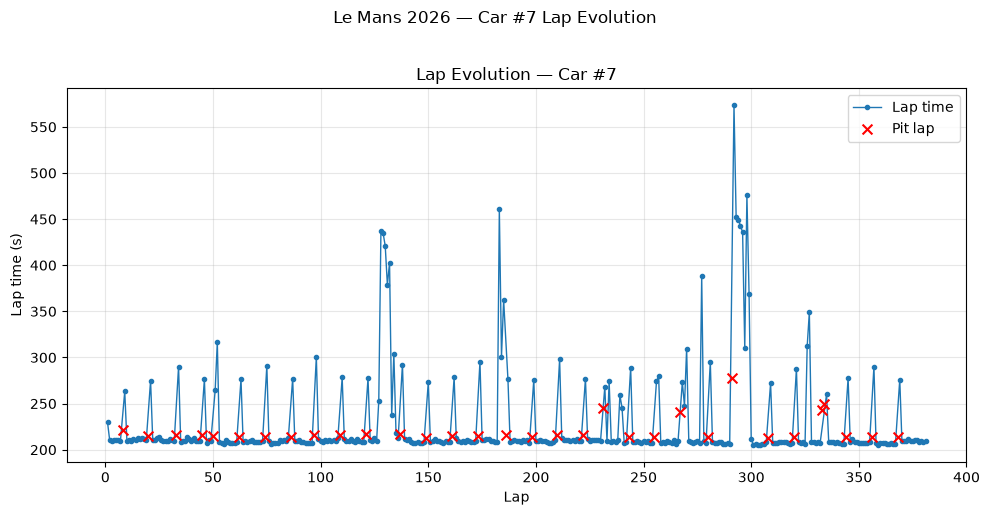

In [17]:
# Lap evolution — winner car
fig = session.plot_lap_evolution(car=str(winner_car))
fig.suptitle(f"Le Mans 2026 — Car #{winner_car} Lap Evolution", y=1.02)
plt.tight_layout()
plt.show()

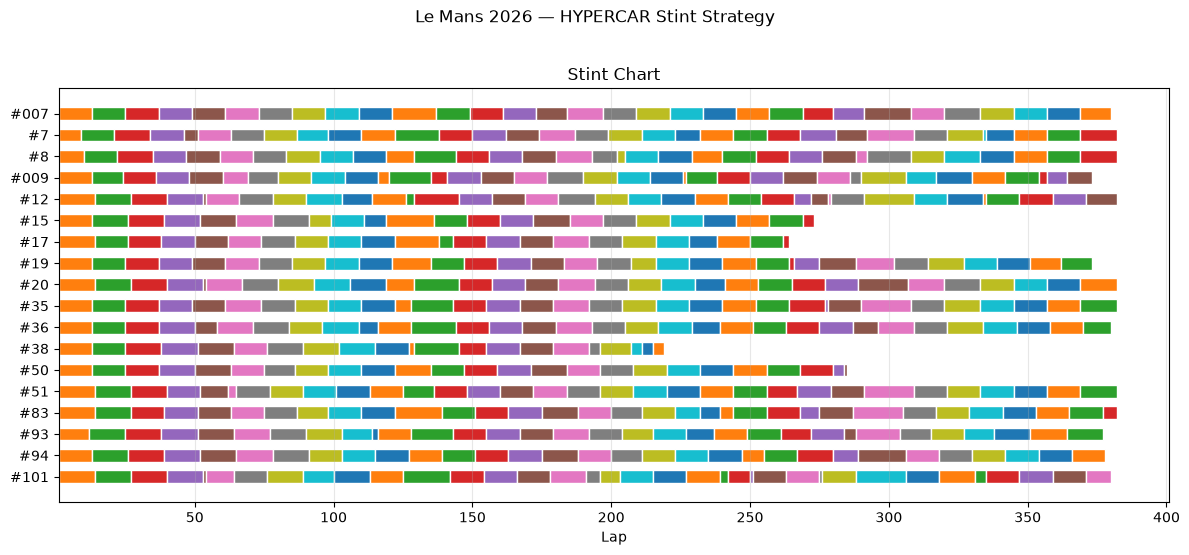

In [18]:
# Stint chart — HYPERCAR class strategy overview
fig = session.plot_stint_chart(car_class="HYPERCAR")
fig.suptitle("Le Mans 2026 — HYPERCAR Stint Strategy", y=1.02)
plt.tight_layout()
plt.show()

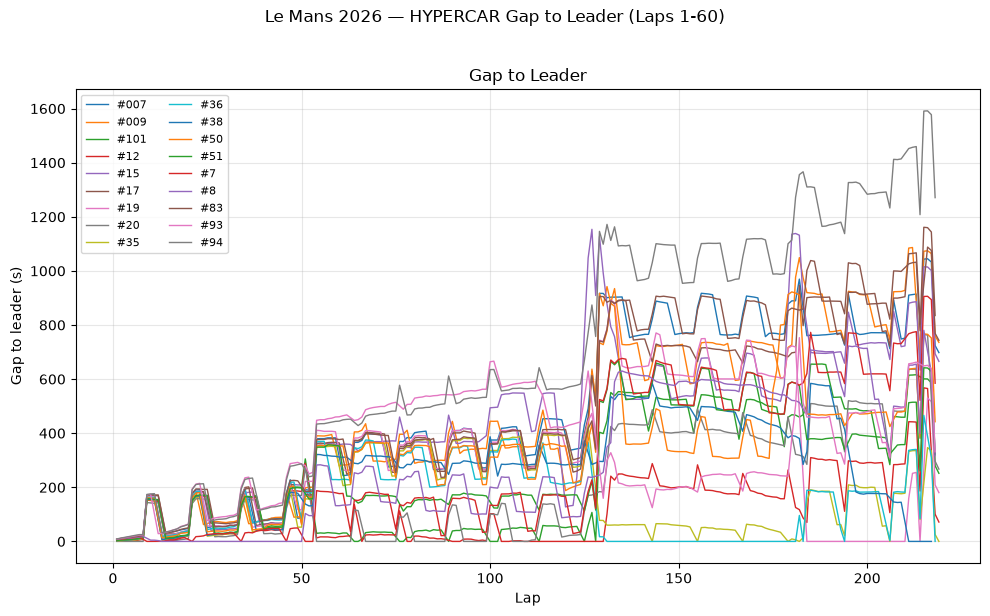

In [19]:
# Gap to leader — first 60 laps
fig = session.plot_gap_to_leader(car_class="HYPERCAR", max_laps=60)
fig.suptitle("Le Mans 2026 — HYPERCAR Gap to Leader (Laps 1-60)", y=1.02)
plt.tight_layout()
plt.show()

## 8. Pit window estimator

In [20]:
# Optimal pit window for the winner
pit_window = session.pit_window(car=str(winner_car))
pit_window[["stint_number", "start_lap", "end_lap", "tyre_age_laps",
            "baseline_pace_s", "degradation_s_per_lap", 
            "early_lap_abs", "ideal_lap_abs", "late_lap_abs",
            "recommendation"]].head(10)

,stint_number,start_lap,end_lap,tyre_age_laps,baseline_pace_s,degradation_s_per_lap,early_lap_abs,ideal_lap_abs,late_lap_abs,recommendation
0,1,1,7,7,210.303,-0.0584,NaN,NaN,NaN,Pace not degrading — pit window driven by fuel...
1,2,9,19,11,210.472,0.1460,NaN,NaN,NaN,Low degradation (+0.146s/lap) — no pace-based ...
2,3,21,32,12,210.711,-0.1348,NaN,NaN,NaN,Pace not degrading — pit window driven by fuel...
3,4,34,44,11,209.585,0.0273,NaN,NaN,NaN,Low degradation (+0.027s/lap) — no pace-based ...
4,5,46,49,4,209.811,1.1395,NaN,NaN,NaN,Low degradation (+1.139s/lap) — no pace-based ...
5,6,51,61,11,208.122,-5.9309,NaN,NaN,NaN,Pace not degrading — pit window driven by fuel...
6,7,63,73,11,209.407,0.0170,NaN,NaN,NaN,Low degradation (+0.017s/lap) — no pace-based ...
7,8,75,85,11,207.680,0.4278,NaN,NaN,NaN,Low degradation (+0.428s/lap) — no pace-based ...
8,9,87,96,10,209.154,-0.3678,NaN,NaN,NaN,Pace not degrading — pit window driven by fuel...
9,10,98,108,11,209.081,0.1459,NaN,NaN,NaN,Low degradation (+0.146s/lap) — no pace-based ...


## 9. Exploring other sessions

The same API works for any series and session.

In [ ]:
# ELMS 2025 — Spa
elms_spa = openwec.Session("ELMS", 2025, "Spa", "Race")
print(elms_spa)

elms_results = elms_spa.results()
elms_results[["position", "car_number", "car_class", "team", "laps_completed"]].head(10)

In [ ]:
# IMSA 2026 — Daytona
imsa = openwec.Session("IMSA", 2026, "Daytona", "Race")
print(imsa)

imsa_results = imsa.results()
imsa_results[["position", "car_number", "car_class", "team", "laps_completed"]].head(10)

---

## Next steps

- [API Documentation](https://api.openwec.com/docs) — full endpoint reference
- [openwec.com](https://openwec.com) — live dashboard
- [GitHub](https://github.com/palomacdev/openwec) — source code
- [Request API key](https://openwec.com/api-keys) — for laps and analytics endpoints